# Classification inIris Dataset using Naive Bayes

### Loading dataset

In [1]:
import numpy as np
import pandas as pd

In [2]:
data = pd.read_csv('E:/Dataset/Iris.csv')

In [26]:
data = data.drop(columns=['Id'])

In [27]:
data.sample(5)

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
104,6.5,3.0,5.8,2.2,Iris-virginica
10,5.4,3.7,1.5,0.2,Iris-setosa
31,5.4,3.4,1.5,0.4,Iris-setosa
86,6.7,3.1,4.7,1.5,Iris-versicolor
148,6.2,3.4,5.4,2.3,Iris-virginica


In [28]:
x = data.iloc[:, :-1]
y = data.iloc[:, -1]

### Transform label column **from categorical to numerical**

In [8]:
from sklearn.preprocessing import LabelEncoder

In [29]:
encoder = LabelEncoder()

In [30]:
y_encoded = encoder.fit_transform(y)

In [31]:
encoder.classes_

array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object)

### Splitting dataset

In [24]:
from sklearn.model_selection import train_test_split

In [32]:
x_train, x_test, y_train, y_test = train_test_split(x, y_encoded, test_size=0.2, random_state=17)

### Visualizing our data to use NAive Bayes

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

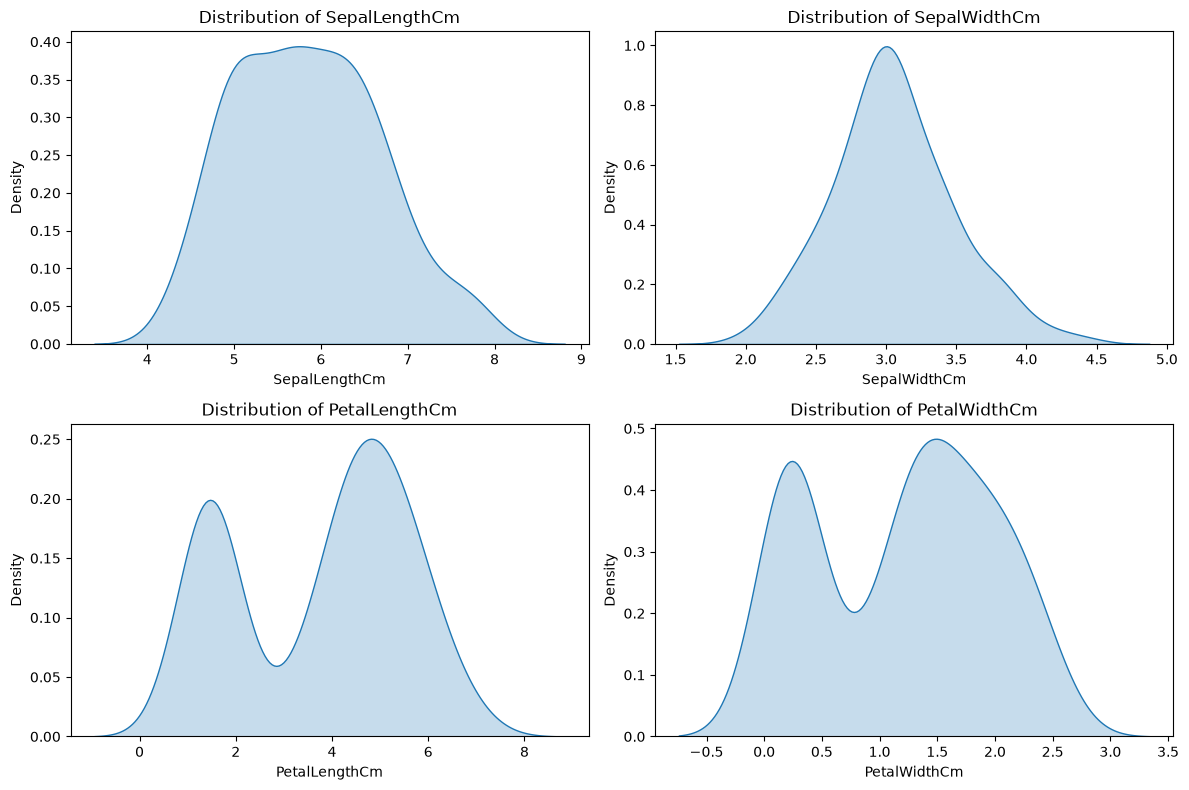

In [45]:
features = ["SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for feature, ax in zip(features, axes.ravel()):
    sns.kdeplot(data=data, x=feature, fill=True, ax=ax)

    ax.set_title(f"Distribution of {feature}")
    ax.set_xlabel(feature)
    ax.set_ylabel("Density")

plt.tight_layout()
plt.show()

In [46]:
data[features].skew()

SepalLengthCm    0.314911
SepalWidthCm     0.334053
PetalLengthCm   -0.274464
PetalWidthCm    -0.104997
dtype: float64

#### - Our data follows almost Normal Distribution

### Training the **Gaussian Naive Bayes** model

In [48]:
from sklearn.naive_bayes import GaussianNB

In [49]:
gaussian_NB = GaussianNB()

In [50]:
gaussian_NB.fit(x_train, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [51]:
y_pred = gaussian_NB.predict(x_test)

### Testing our model

In [52]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [53]:
accuracy_score(y_test, y_pred)

0.9666666666666667

In [56]:
confusion_matrix(y_test, y_pred)

array([[ 7,  0,  0],
       [ 0, 11,  0],
       [ 0,  1, 11]])

In [60]:
print(classification_report(y_test, y_pred, target_names = ['Setosa', 'Versicolor', 'Versinica']))

              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00         7
  Versicolor       0.92      1.00      0.96        11
   Versinica       1.00      0.92      0.96        12

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30

